# Define Metric - Mean Reversion Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("eurusd_price.csv", parse_dates=["date"], index_col="date")
df.head()

,price
date,
2022-10-25 01:00:00,0.98868
2022-10-25 02:00:00,0.98843
2022-10-25 03:00:00,0.98943
2022-10-25 04:00:00,0.98878
2022-10-25 05:00:00,0.98846


In [3]:
df["3m"] = df.index.to_period("Q")
df[["price", "3m"]].head()

,price,3m
date,,
2022-10-25 01:00:00,0.98868,2022Q4
2022-10-25 02:00:00,0.98843,2022Q4
2022-10-25 03:00:00,0.98943,2022Q4
2022-10-25 04:00:00,0.98878,2022Q4
2022-10-25 05:00:00,0.98846,2022Q4


In [4]:
df["3m"].value_counts().sort_index()

3m
2022Q4    1165
2023Q1    1551
2023Q2    1560
2023Q3    1559
2023Q4    1537
2024Q1    1533
2024Q2    1560
2024Q3    1573
2024Q4    1560
2025Q1    1507
2025Q2    1560
2025Q3    1571
2025Q4     790
Freq: Q-DEC, Name: count, dtype: int64

In [5]:
counts = df["3m"].value_counts()

# keep only quarters with at least 1500 observations
valid_quarters = counts[counts > 1500].index

df = df[df["3m"].isin(valid_quarters)]
df["3m"].value_counts().sort_index()

3m
2023Q1    1551
2023Q2    1560
2023Q3    1559
2023Q4    1537
2024Q1    1533
2024Q2    1560
2024Q3    1573
2024Q4    1560
2025Q1    1507
2025Q2    1560
2025Q3    1571
Freq: Q-DEC, Name: count, dtype: int64

In [6]:
## Monthly Midpoint
# month label

df["m"] = df.index.to_period("M")
df["md"] = df.groupby("m")["price"].transform(lambda x: (x.max() + x.min()) / 2)

In [7]:
## 3M Midpoint
df["md3"] = df.groupby("3m")["md"].transform("mean")
df[["price","md","md3"]].head()

,price,md,md3
date,,,
2023-01-02 07:00:00,1.06967,1.07075,1.073523
2023-01-02 08:00:00,1.06935,1.07075,1.073523
2023-01-02 09:00:00,1.06791,1.07075,1.073523
2023-01-02 10:00:00,1.06788,1.07075,1.073523
2023-01-02 11:00:00,1.06784,1.07075,1.073523


In [8]:
## Deviation of Monthly Midpoint from 3M Midpoint

df["d"] = ((df["md3"] - df["md"]) / df["md3"]).abs()
df[["md","md3","d"]].head()

,md,md3,d
date,,,
2023-01-02 07:00:00,1.07075,1.073523,0.002583
2023-01-02 08:00:00,1.07075,1.073523,0.002583
2023-01-02 09:00:00,1.07075,1.073523,0.002583
2023-01-02 10:00:00,1.07075,1.073523,0.002583
2023-01-02 11:00:00,1.07075,1.073523,0.002583


In [9]:
## Distance from 3M Midpoint

base = (df["md3"] - df["d"])

dist_abs = (df["price"] - base).abs()
direction = np.where(df["price"].shift(-1) < df["price"], -1, 1)

df["dist"] = dist_abs
df["dist_next"] = df["dist"].shift(-1) * direction

df.head()

,price,3m,m,md,md3,d,dist,dist_next
date,,,,,,,,
2023-01-02 07:00:00,1.06967,2023Q1,2023-01,1.07075,1.073523,0.002583,0.00127,-0.00159
2023-01-02 08:00:00,1.06935,2023Q1,2023-01,1.07075,1.073523,0.002583,0.00159,-0.00303
2023-01-02 09:00:00,1.06791,2023Q1,2023-01,1.07075,1.073523,0.002583,0.00303,-0.00306
2023-01-02 10:00:00,1.06788,2023Q1,2023-01,1.07075,1.073523,0.002583,0.00306,-0.00310
2023-01-02 11:00:00,1.06784,2023Q1,2023-01,1.07075,1.073523,0.002583,0.00310,0.00258


In [10]:
## Mean Reversion Event

df["mr"] = (df["dist_next"].abs() < df["dist"].abs()).astype(int)
df[["price","dist","dist_next","mr"]].head()

,price,dist,dist_next,mr
date,,,,
2023-01-02 07:00:00,1.06967,0.00127,-0.00159,0
2023-01-02 08:00:00,1.06935,0.00159,-0.00303,0
2023-01-02 09:00:00,1.06791,0.00303,-0.00306,0
2023-01-02 10:00:00,1.06788,0.00306,-0.00310,0
2023-01-02 11:00:00,1.06784,0.00310,0.00258,1


In [11]:
## Mean Reversion Score per 3M

mr_score = df.groupby("3m")["mr"].mean()
mr_score

3m
2023Q1    0.497099
2023Q2    0.496795
2023Q3    0.500321
2023Q4    0.475602
2024Q1    0.510111
2024Q2    0.482692
2024Q3    0.499682
2024Q4    0.512821
2025Q1    0.498341
2025Q2    0.493590
2025Q3    0.494589
Freq: Q-DEC, Name: mr, dtype: float64

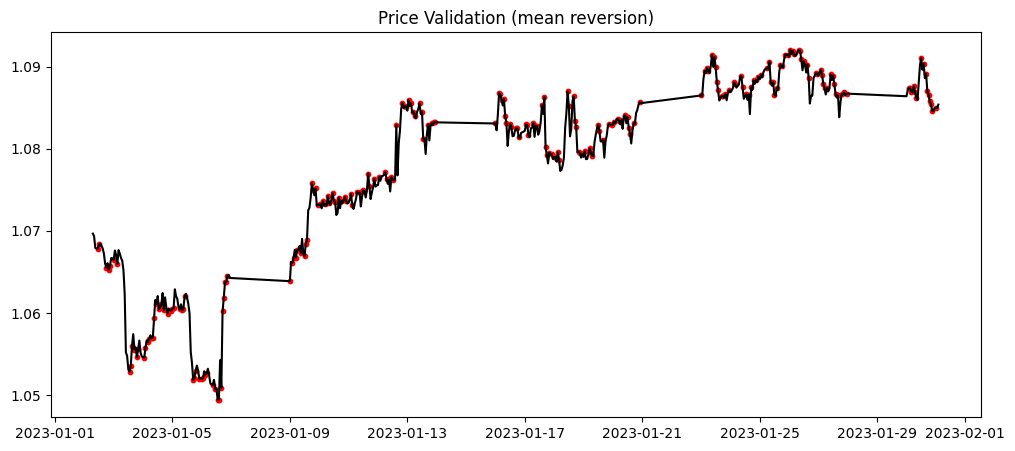

In [12]:
n = 500
d = df.iloc[:n]

plt.figure(figsize=(12,5))
plt.plot(d.index, d["price"], color="black")
plt.scatter(d[d["mr"]==1].index, d[d["mr"]==1]["price"], color="red", s=10)
plt.title("Price Validation (mean reversion)")

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/ValidationPriceMeanReversion.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
df.to_csv(r"C:\Users\LENOVO\AlgoTrading_Research\statistical-range-detection\data\processed\eurusd_mr_v1.csv")